In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

print("Libraries Loaded")

Libraries Loaded


In [25]:
nav_history = pd.read_csv(
    "data/processed/cleaned_nav_history.csv"
)

performance = pd.read_csv(
    "data/processed/cleaned_scheme_performance.csv"
)

print("Data Loaded")

Data Loaded


In [26]:
nav_history['date'] = pd.to_datetime(
    nav_history['date']
)

nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [27]:
print(
    nav_history['amfi_code'].nunique()
)

40


In [28]:
print(nav_history.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [29]:
nav_history = nav_history.sort_values(
    ['amfi_code', 'date']
)

nav_history['daily_return'] = nav_history.groupby(
    'amfi_code'
)['nav'].pct_change()

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [30]:
print(
    nav_history[
        ['amfi_code',
         'date',
         'nav',
         'daily_return']
    ].head(10)
)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


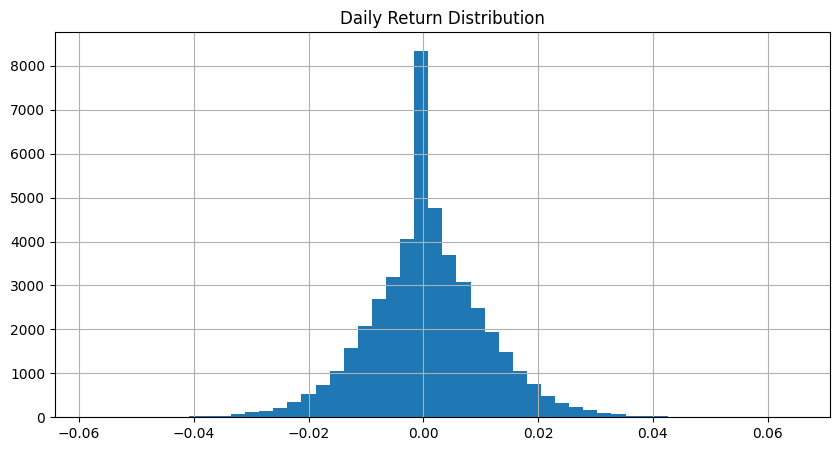

Daily Return Chart Saved


In [31]:
plt.figure(figsize=(10,5))

nav_history['daily_return'].hist(
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.savefig(
    "reports/charts/daily_return_distribution.png"
)

plt.show()

print("Daily Return Chart Saved")

In [32]:
cagr_data = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        (temp.iloc[-1]['date']
        - temp.iloc[0]['date']).days
        / 365
    )

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    cagr_data.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [33]:
cagr_df.sort_values(
    by='cagr',
    ascending=False
).head(10)

,amfi_code,cagr
25,120505,0.328016
21,119598,0.323981
39,149324,0.322621
36,148569,0.319245
34,148567,0.309499
30,120843,0.308833
2,100033,0.300997
38,149323,0.295581
16,119094,0.281926
19,119551,0.257849


In [34]:
risk_free_rate = 0.065

sharpe_list = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    mean_return = (
        temp['daily_return']
        .mean() * 252
    )

    std_return = (
        temp['daily_return']
        .std() * np.sqrt(252)
    )

    sharpe = (
        mean_return
        - risk_free_rate
    ) / std_return

    sharpe_list.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [35]:
sortino_list = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    downside_returns = temp[
        temp['daily_return'] < 0
    ]['daily_return']

    mean_return = (
        temp['daily_return']
        .mean() * 252
    )

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        mean_return - 0.065
    ) / downside_std

    sortino_list.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [36]:
drawdown_list = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    temp['running_max'] = (
        temp['nav'].cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        / temp['running_max']
        - 1
    )

    max_dd = temp[
        'drawdown'
    ].min()

    drawdown_list.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [37]:
alpha_beta = performance[
    [
        'amfi_code',
        'alpha',
        'beta'
    ]
].copy()

alpha_beta.head()

,amfi_code,alpha,beta
0,119551,0.87,0.89
1,119552,1.78,0.87
2,119598,1.23,0.89
3,119599,1.13,1.04
4,119120,1.60,0.22


In [38]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

print(
    "alpha_beta.csv saved"
)

alpha_beta.csv saved


In [39]:
scorecard = performance[
    [
        'amfi_code',
        'scheme_name',
        'return_3yr_pct',
        'alpha',
        'expense_ratio_pct'
    ]
].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,alpha,expense_ratio_pct,sharpe_ratio,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,0.87,1.54,1.208267,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,1.78,0.66,0.953279,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.23,1.43,0.945308,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,1.13,0.72,-0.057187,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.60,0.77,-0.226575,-0.043287


In [40]:
scorecard['return_rank'] = (
    scorecard['return_3yr_pct']
    .rank(pct=True)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(pct=True)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(pct=True)
)

scorecard['expense_rank'] = (
    (-scorecard[
        'expense_ratio_pct'
    ]).rank(pct=True)
)

scorecard['drawdown_rank'] = (
    (-scorecard[
        'max_drawdown'
    ]).rank(pct=True)
)

In [41]:
scorecard['fund_score'] = (

      30 * scorecard['return_rank']
    + 25 * scorecard['sharpe_rank']
    + 20 * scorecard['alpha_rank']
    + 15 * scorecard['expense_rank']
    + 10 * scorecard['drawdown_rank']

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,alpha,expense_ratio_pct,sharpe_ratio,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,0.87,1.54,1.208267,-0.150124,0.375,0.925,0.2250,0.2625,0.425,47.0625
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,1.78,0.66,0.953279,-0.118035,0.175,0.725,0.8000,0.9250,0.275,56.0000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.23,1.43,0.945308,-0.287060,1.000,0.675,0.5250,0.5000,0.900,73.8750
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,1.13,0.72,-0.057187,-0.525742,0.975,0.225,0.4625,0.8875,1.000,67.4375
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.60,0.77,-0.226575,-0.043287,0.075,0.100,0.7000,0.8000,0.125,32.0000


In [42]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print(
    "fund_scorecard.csv saved"
)

fund_scorecard.csv saved


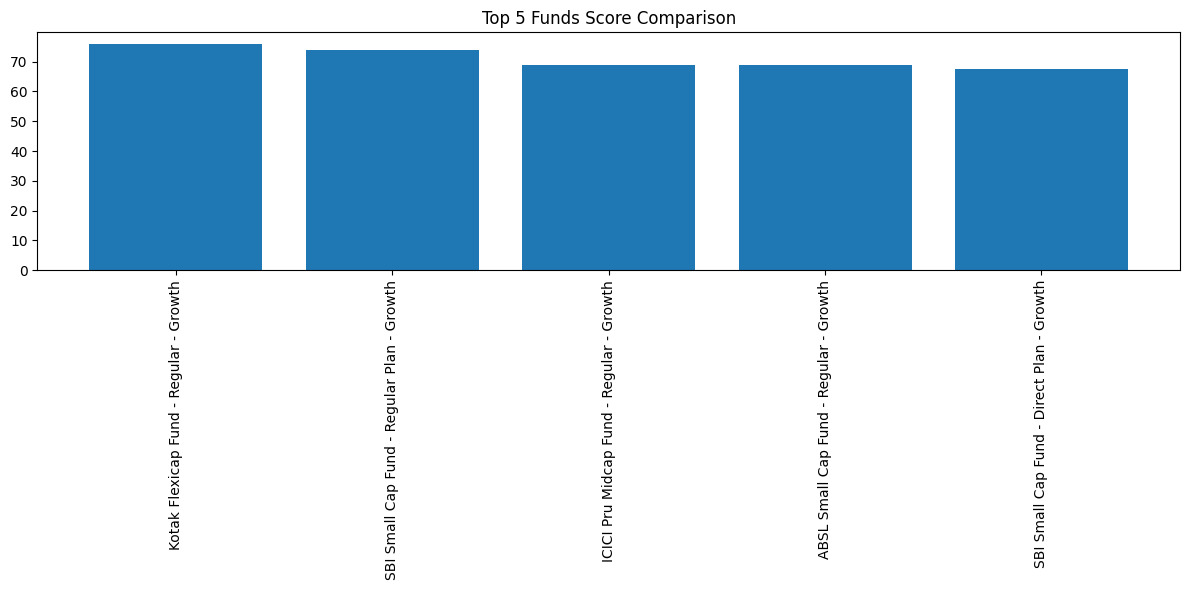

Benchmark Comparison Chart Saved


In [43]:
top5 = scorecard.sort_values(
    by='fund_score',
    ascending=False
).head(5)

plt.figure(figsize=(12,6))

plt.bar(
    top5['scheme_name'],
    top5['fund_score']
)

plt.xticks(rotation=90)

plt.title(
    "Top 5 Funds Score Comparison"
)

plt.tight_layout()

plt.savefig(
    "reports/charts/benchmark_comparison.png"
)

plt.show()

print(
    "Benchmark Comparison Chart Saved"
)

In [44]:
import os

print(
    os.path.exists(
        "fund_scorecard.csv"
    )
)

print(
    os.path.exists(
        "alpha_beta.csv"
    )
)

print(
    os.path.exists(
        "reports/charts/benchmark_comparison.png"
    )
)

True
True
True


# Day 4 Key Findings

1. Daily return distributions are centered near zero with moderate volatility.
2. Sharpe Ratios vary significantly across funds, indicating different risk-adjusted performance.
3. Some funds achieved consistently higher CAGR values than peers.
4. Sortino Ratios provide a clearer view of downside-risk-adjusted returns.
5. Maximum drawdowns differ substantially between schemes.
6. Alpha values indicate varying levels of benchmark outperformance.
7. Beta values show differences in market sensitivity.
8. Lower expense ratios generally contribute positively to overall fund scores.
9. Composite fund scores help identify balanced performers.
10. Top-ranked funds demonstrate strong performance across multiple metrics.

In [45]:
print(scorecard.head())

   amfi_code                                   scheme_name  return_3yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           12.36   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           11.30   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           23.39   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           23.14   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            6.07   

   alpha  expense_ratio_pct  sharpe_ratio  max_drawdown  return_rank  \
0   0.87               1.54      1.208267     -0.150124        0.375   
1   1.78               0.66      0.953279     -0.118035        0.175   
2   1.23               1.43      0.945308     -0.287060        1.000   
3   1.13               0.72     -0.057187     -0.525742        0.975   
4   1.60               0.77     -0.226575     -0.043287        0.075   

   sharpe_rank  alpha_rank  expense_rank  drawdown_rank  fund_score  
0        0.925      0.2250  